# V3 — Classificador com Look-ahead (67 Features)

Pipeline completo para a versão V3 do classificador de qualidade de lances de xadrez.
Adiciona 15 features de look-ahead às 52 da V2: deltas antes/depois do lance, resposta do adversário, Static Exchange Evaluation (SEE).

---

## 1. Setup

In [1]:
import json
import os
import random
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*", category=UserWarning)
plt.rcParams.update({"font.size": 11, "figure.facecolor": "white"})
sns.set_style("whitegrid")

PROJECT_ROOT = Path("..").resolve()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = Path("data")

from version_config import V3
from notebook_utils import *

config = V3

print(f"Versão: {config.label}")
print(f"Diretório de trabalho: {os.getcwd()}")
print("Setup OK")

Versão: V3 — posicional + tática + look-ahead (67 features)
Diretório de trabalho: /Users/noel/Faculdade/ML/Chess
Setup OK


In [2]:
RERUN_PIPELINE = False
print(f"RERUN_PIPELINE = {RERUN_PIPELINE}")
if RERUN_PIPELINE:
    print("⚠️  O pipeline completo será re-executado.")
else:
    print("Usando dados pré-computados.")

RERUN_PIPELINE = False
Usando dados pré-computados.


---

## 2. Dados

Os dados (coleta, filtragem, rotulagem) são os mesmos da V1/V2 — o que muda é a engenharia de features.

In [3]:
df_filtered = pd.read_csv(DATA_DIR / "filtered" / "moves_filtered.csv")
print_dataset_stats(df_filtered)

  DATASET FILTRADO
  Partidas       : 2,911
  Lances (total) : 136,620
  Lances/partida : 46.9
  Colunas        : ['game_id', 'game_site', 'white_elo', 'black_elo', 'time_control', 'result', 'move_number', 'color', 'fen_before', 'move_uci', 'move_san']


In [4]:
df_scored = pd.read_csv(DATA_DIR / "labeled" / "moves_all_scored.csv")
df_labeled = pd.read_csv(DATA_DIR / "labeled" / "moves_labeled.csv")
print_labeling_stats(df_scored, df_labeled)

  ROTULAGEM
  Lances avaliados      : 136,620
  Bom (δ ≥ −50 cp)      : 92,197 (67.5%)
  Descartado (cinzenta) : 27,330 (20.0%)
  Ruim (δ ≤ −150 cp)    : 17,093 (12.5%)
  ──────────────────────
  Dataset final         : 109,290 (bom + ruim)
  Ratio bom:ruim        : 5.39:1


---

## 3. Engenharia de Features — V3 (52 + 15 = 67)

### Novas features de look-ahead (+15)

| Grupo | Qtd. | Features |
|-------|------|----------|
| **Deltas (antes→depois)** | 8 | Δ hanging, Δ tensão, Δ mobilidade, Δ ameaças, Δ atacantes do rei |
| **Resposta do adversário** | 4 | Melhor captura disponível, pode dar xeque, capturas boas, criou peça indefesa |
| **SEE** | 3 | SEE do lance, pior SEE contra jogador, é captura perdedora |

**Evolução conceitual:**

| Versão | Pergunta que responde |
|--------|----------------------|
| V1 | "Como é a posição?" |
| V2 | "Que perigos existem?" |
| **V3** | **"O lance melhorou ou piorou a posição?"** |

In [5]:
if RERUN_PIPELINE:
    from extract_features import run as extract_run
    print(f"Extraindo {config.n_features} features V{config.version}...")
    extract_run(num_workers=6, batch_size=1000, v2=True, v3=True)
else:
    print(f"⏭️  Extração de features pulada.")
    print(f"   → {config.features_csv}")

⏭️  Extração de features pulada.
   → data/features/features_v3.csv


In [6]:
df_features = pd.read_csv(config.features_csv)
feature_cols = [c for c in df_features.columns if c != "label"]
print_features_stats(df_features, config)
print(f"\nEstatísticas descritivas:")
df_features[feature_cols].describe().round(2)

  FEATURES — V3
  Fonte       : data/features/features_v3.csv
  Linhas      : 109,290
  Features    : 67
  Valores nulos: 0

Distribuição do label:
label
bom     92197
ruim    17093

Estatísticas descritivas:


,white_pawns,white_knights,white_bishops,white_rooks,white_queens,black_pawns,black_knights,black_bishops,black_rooks,black_queens,...,delta_mobility_opponent,delta_contested_squares,delta_king_attackers_player,opponent_best_capture_value,opponent_can_check,opponent_num_good_captures,created_hanging_self,see_of_move,worst_see_against_player,is_losing_capture
count,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,...,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00
mean,5.99,0.98,1.05,1.67,0.70,6.00,0.97,1.08,1.66,0.70,...,-0.74,0.00,-0.09,2.00,0.46,0.26,0.07,0.50,-0.86,0.02
std,1.44,0.77,0.77,0.59,0.46,1.44,0.78,0.76,0.60,0.46,...,13.88,2.22,0.48,1.98,0.50,0.56,0.26,1.55,1.77,0.13
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,-61.00,-16.00,-5.00,0.00,0.00,0.00,0.00,-8.00,-9.00,0.00
25%,5.00,0.00,0.00,1.00,0.00,5.00,0.00,0.00,1.00,0.00,...,-2.00,-1.00,0.00,1.00,0.00,0.00,0.00,0.00,-1.00,0.00
50%,6.00,1.00,1.00,2.00,1.00,6.00,1.00,1.00,2.00,1.00,...,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7.00,2.00,2.00,2.00,1.00,7.00,2.00,2.00,2.00,1.00,...,0.00,1.00,0.00,3.00,1.00,0.00,0.00,0.00,0.00,0.00
max,8.00,2.00,2.00,2.00,2.00,8.00,3.00,2.00,3.00,2.00,...,65.00,12.00,5.00,9.00,1.00,9.00,1.00,9.00,0.00,1.00


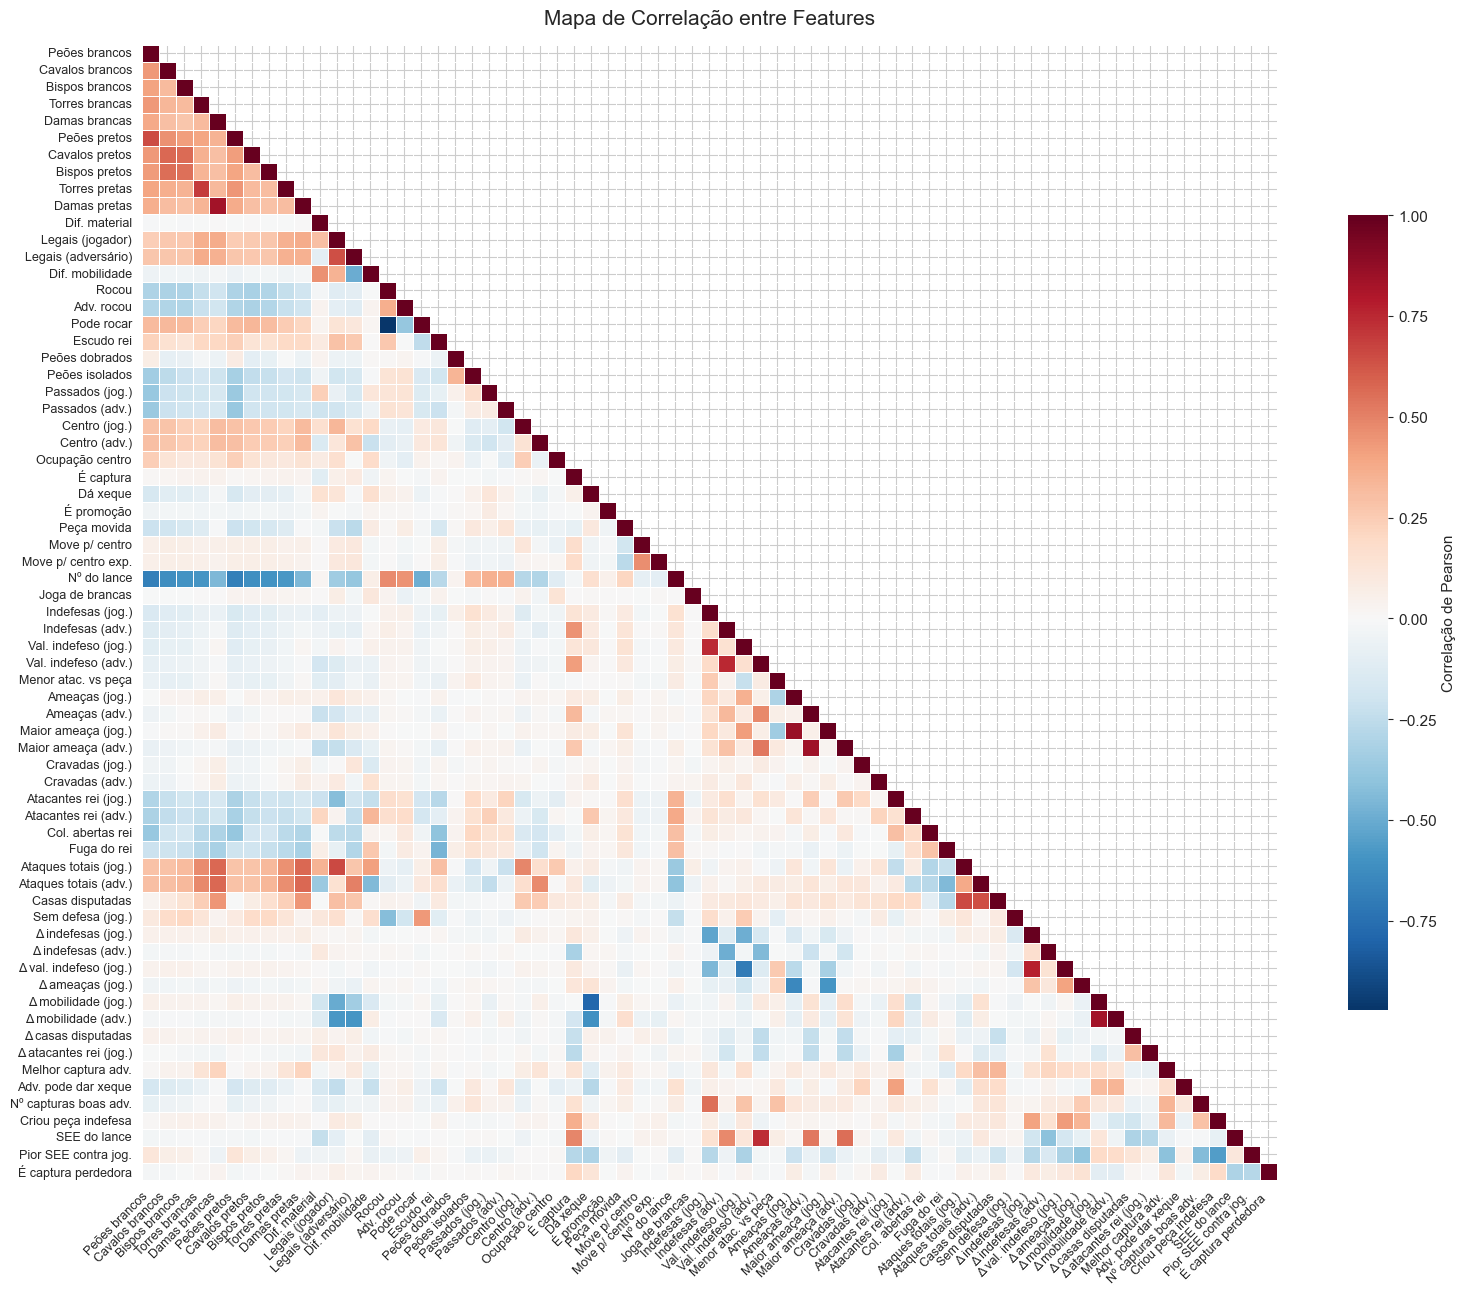

Pares com |correlação| > 0.7:
  Rocou                      ↔  Pode rocar                 r = -0.970
  Ameaças (jog.)             ↔  Maior ameaça (jog.)        r = +0.857
  Ameaças (adv.)             ↔  Maior ameaça (adv.)        r = +0.842
  Damas brancas              ↔  Damas pretas               r = +0.836
  Δ mobilidade (jog.)        ↔  Δ mobilidade (adv.)        r = +0.831
  Dá xeque                   ↔  Δ mobilidade (jog.)        r = -0.792
  Δ indefesas (jog.)         ↔  Δ val. indefeso (jog.)     r = +0.770
  Indefesas (adv.)           ↔  Val. indefeso (adv.)       r = +0.753
  Indefesas (jog.)           ↔  Val. indefeso (jog.)       r = +0.740
  Val. indefeso (adv.)       ↔  SEE do lance               r = +0.731


In [7]:
plot_correlation_matrix(df_features, feature_cols)

---

## 4. Treino dos Modelos

- Split **70/15/15** com estratificação
- `class_weight="balanced"`
- `GridSearchCV` com 5 folds, métrica F1 da classe "ruim"

In [8]:
X = df_features.drop(columns=["label"])
y = (df_features["label"] == "ruim").astype(int)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=RANDOM_SEED
)

print_split_info(X_train, y_train, X_val, y_val, X_test, y_test)

  SPLIT DOS DADOS
  Treino    : 76,546 amostras  (bom=64,574, ruim=11,972, 15.6% ruim)
  Validação : 16,350 amostras  (bom=13,793, ruim=2,557, 15.6% ruim)
  Teste     : 16,394 amostras  (bom=13,830, ruim=2,564, 15.6% ruim)


In [9]:
if RERUN_PIPELINE:
    from train_models import run as train_run
    print(f"Treinando modelos V{config.version}...")
    train_run(v2=config.v2_flag, v3=config.v3_flag)
else:
    print(f"⏭️  Treino pulado (usando modelos pré-treinados de {config.models_dir}).")

dt, rf, feature_names = config.load_models()
print_model_params(dt, rf, config)

⏭️  Treino pulado (usando modelos pré-treinados de data/models_v3).

  DECISION TREE V3 — Melhores hiperparâmetros
  criterion        : entropy
  max_depth        : 10
  min_samples_leaf : 20
  class_weight     : balanced

  RANDOM FOREST V3 — Melhores hiperparâmetros
  n_estimators     : 200
  max_depth        : 15
  min_samples_leaf : 10
  class_weight     : balanced


---

## 5. Avaliação

Avaliação no **conjunto de teste** — nunca usado no treino nem no tuning.

In [10]:
print_classification_reports(dt, rf, X_test, y_test)

  DECISION TREE — Classification Report
              precision    recall  f1-score   support

         bom       0.91      0.68      0.78     13830
        ruim       0.27      0.64      0.38      2564

    accuracy                           0.68     16394
   macro avg       0.59      0.66      0.58     16394
weighted avg       0.81      0.68      0.72     16394

  RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

         bom       0.90      0.83      0.87     13830
        ruim       0.37      0.52      0.43      2564

    accuracy                           0.78     16394
   macro avg       0.64      0.68      0.65     16394
weighted avg       0.82      0.78      0.80     16394



In [11]:
df_results = build_results_table(dt, rf, X_test, y_test)
print("Tabela comparativa — Conjunto de teste:\n")
df_results

Tabela comparativa — Conjunto de teste:



,Modelo,Accuracy,F1 (bom),F1 (ruim),Recall (ruim),Precision (ruim),ROC-AUC
0,Decision Tree,0.6762,0.7806,0.3821,0.6400,0.2723,0.7176
1,Random Forest,0.7849,0.8673,0.4312,0.5215,0.3676,0.7678


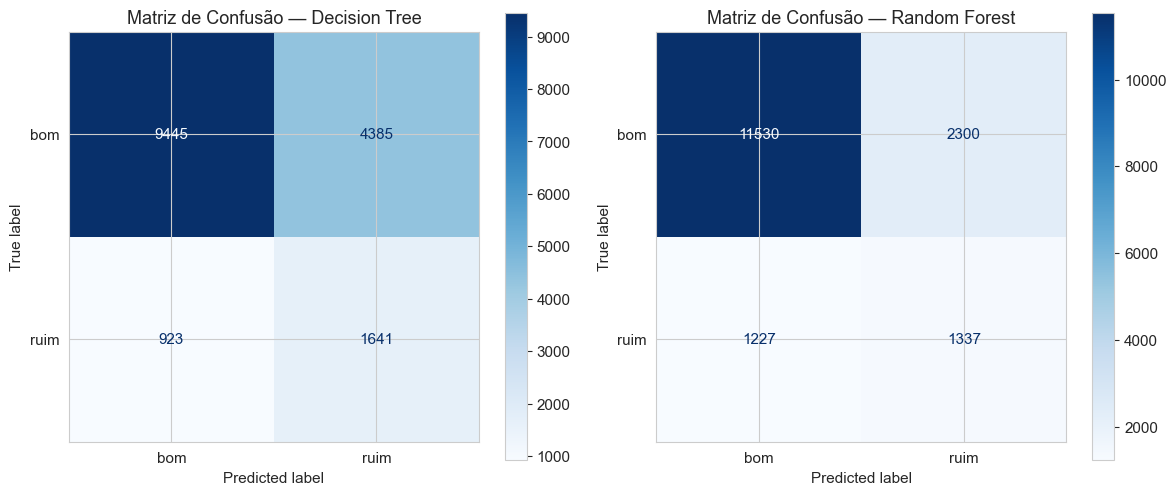

In [12]:
plot_confusion_matrices(dt, rf, X_test, y_test)

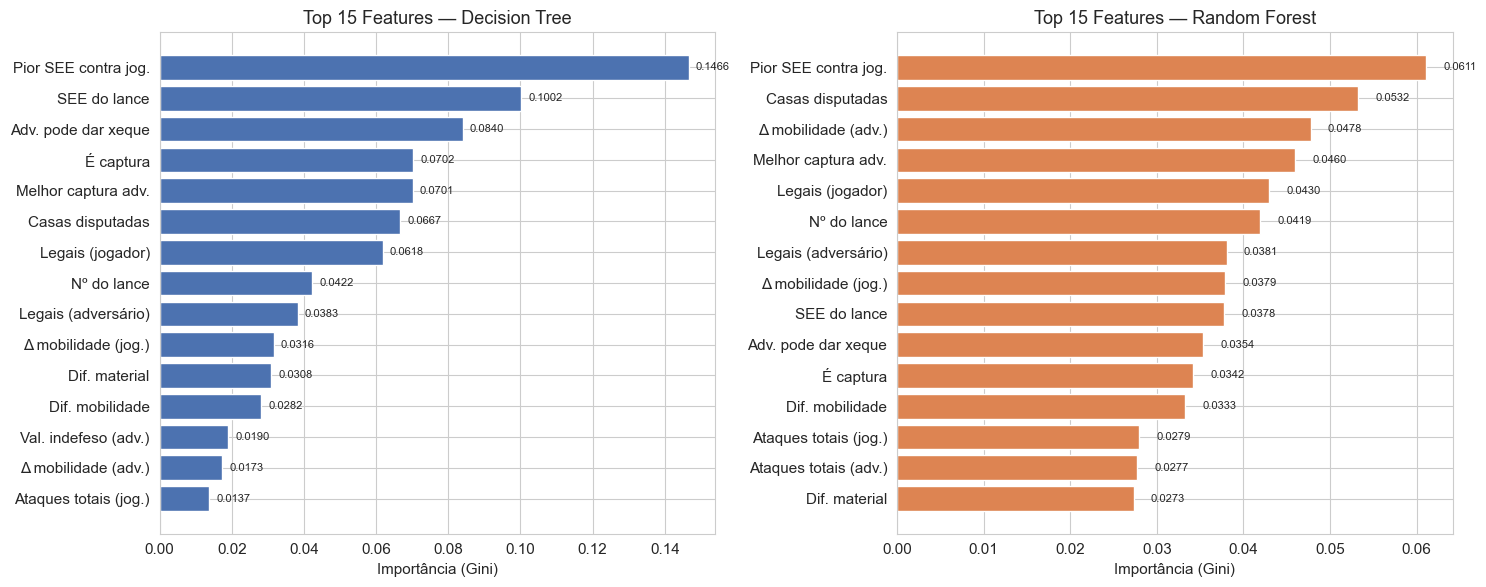

In [13]:
plot_feature_importances_side_by_side(dt, rf, feature_names)

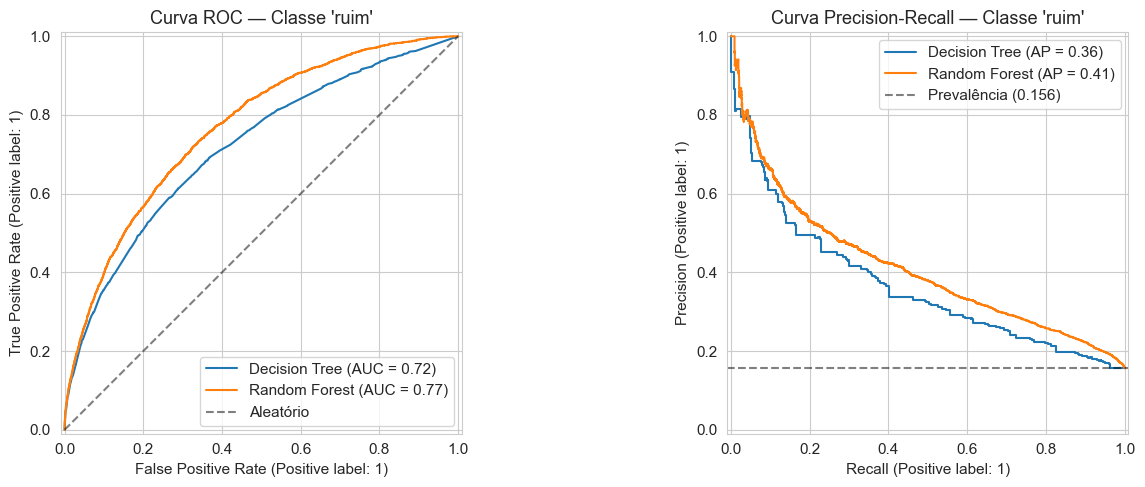

In [14]:
plot_roc_pr_curves(dt, rf, X_test, y_test)

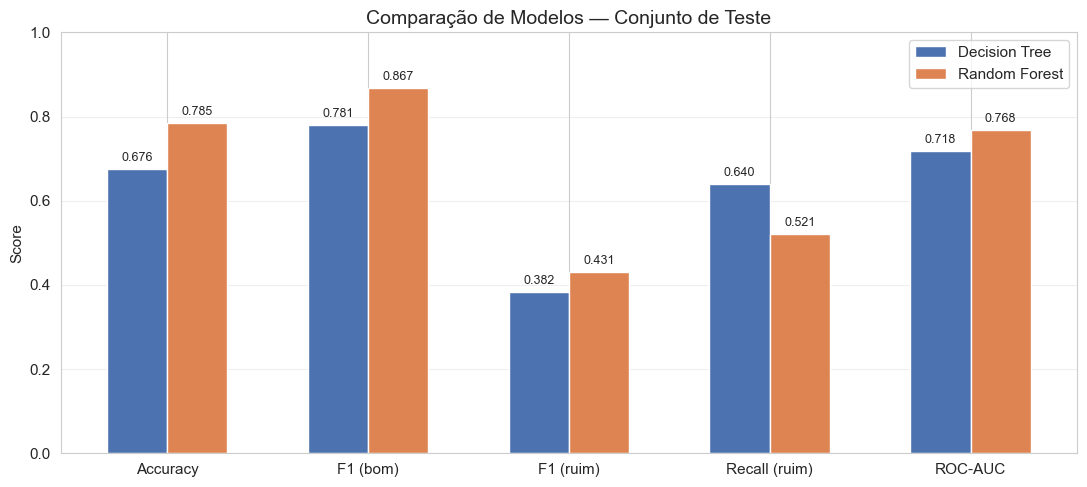

In [15]:
plot_metrics_comparison(dt, rf, X_test, y_test)

/Users/noel/Faculdade/ML/Chess/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/noel/Faculdade/ML/Chess/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/noel/Faculdade/ML/Chess/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/noel/Faculdade/ML/Chess/

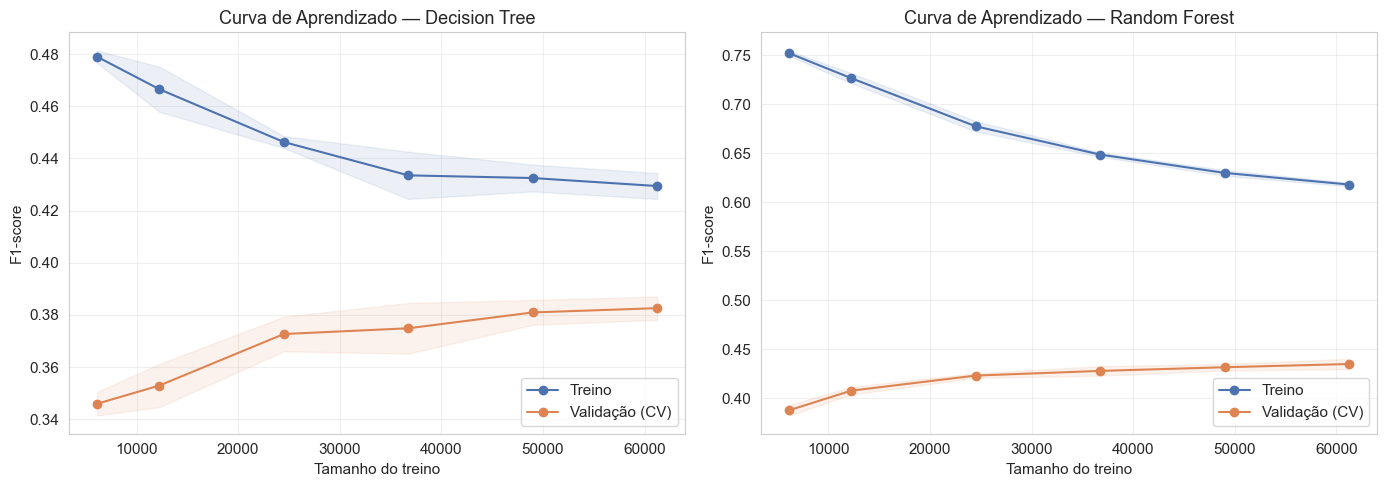

In [22]:
plot_learning_curves(dt, rf, X_train, y_train)

### Importância das Features por Origem (V1/V2/V3)

As features são coloridas pela versão de origem para visualizar a contribuição de cada grupo.

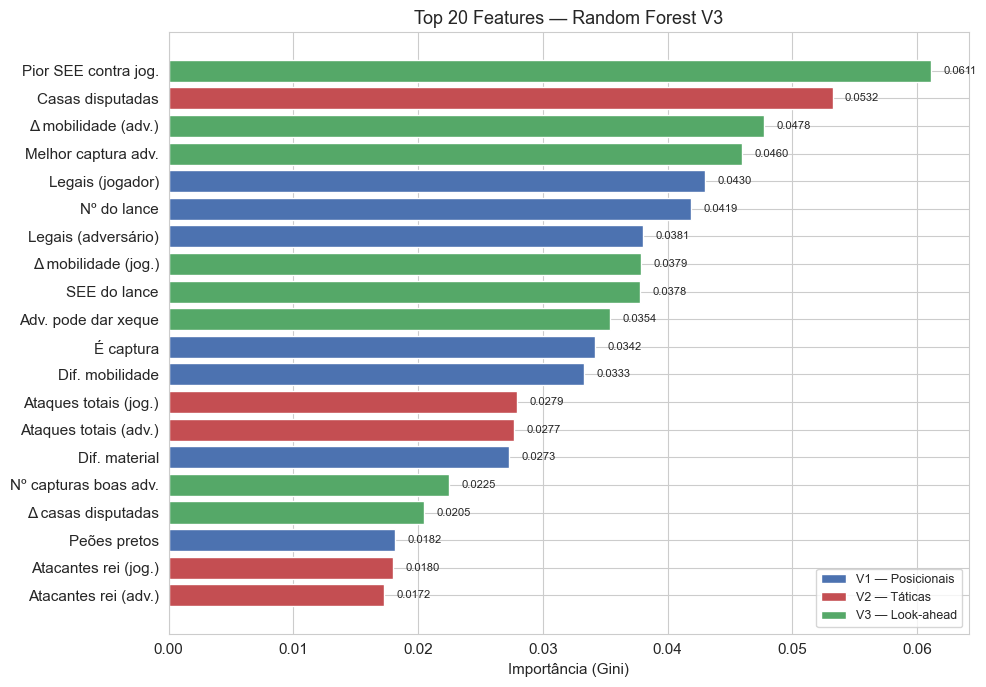

In [17]:
from version_config import V1, V2

_, _, v1_names = V1.load_models()
_, _, v2_names = V2.load_models()

v3_new_features = [
    "delta_hanging_player", "delta_hanging_opponent", "delta_hanging_value_player",
    "delta_threats_against_player", "delta_mobility_player", "delta_mobility_opponent",
    "delta_contested_squares", "delta_king_attackers_player",
    "opponent_best_capture_value", "opponent_can_check", "opponent_num_good_captures",
    "created_hanging_self", "see_of_move", "worst_see_against_player", "is_losing_capture",
]

plot_top_features_colored(rf, feature_names, v1_names, v2_names, v3_new_features)

---

## 6. Diagnóstico V3

O look-ahead de 1 ply resolve ameaças simples, mas não captura combinações de 2+ lances (sacrifícios, mating patterns). O limite teórico com features manuais está próximo.

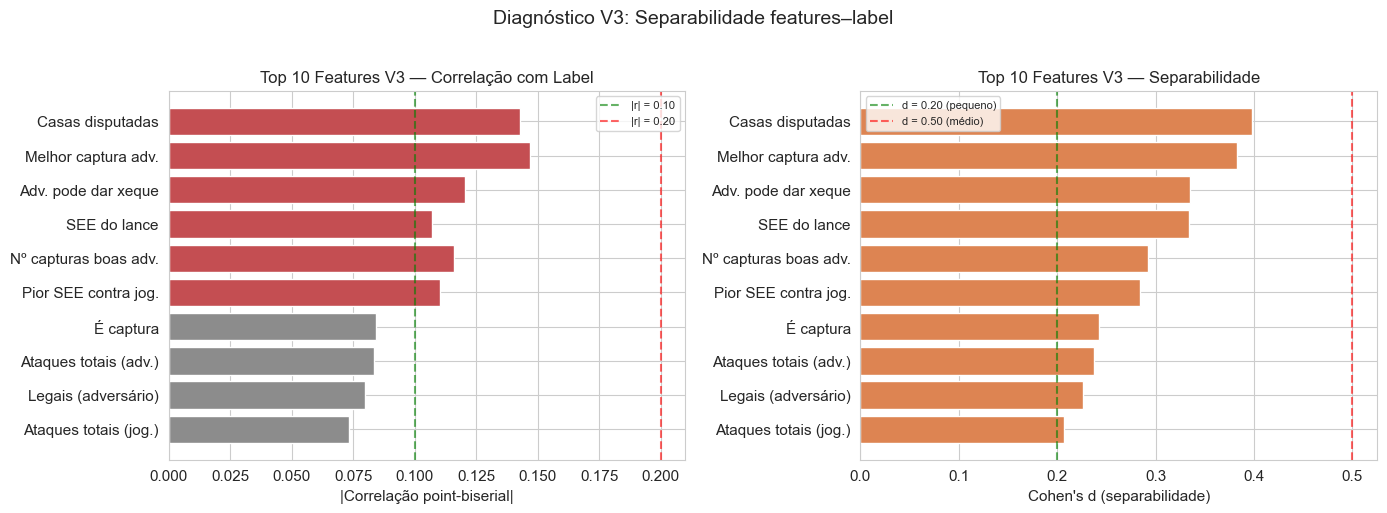

Melhor feature: contested_squares → |r| = 0.143, Cohen's d = 0.398
Features com |r| ≥ 0.10: 6


In [18]:
plot_diagnostic(df_features, feature_cols, "V3")

---

## 7. Interpretação

### Regras da Árvore de Decisão

Na V3, a 1ª decisão da árvore passou de "é captura?" (V1) para "qual o pior resultado de troca?" — o modelo evoluiu para avaliar **consequências**.

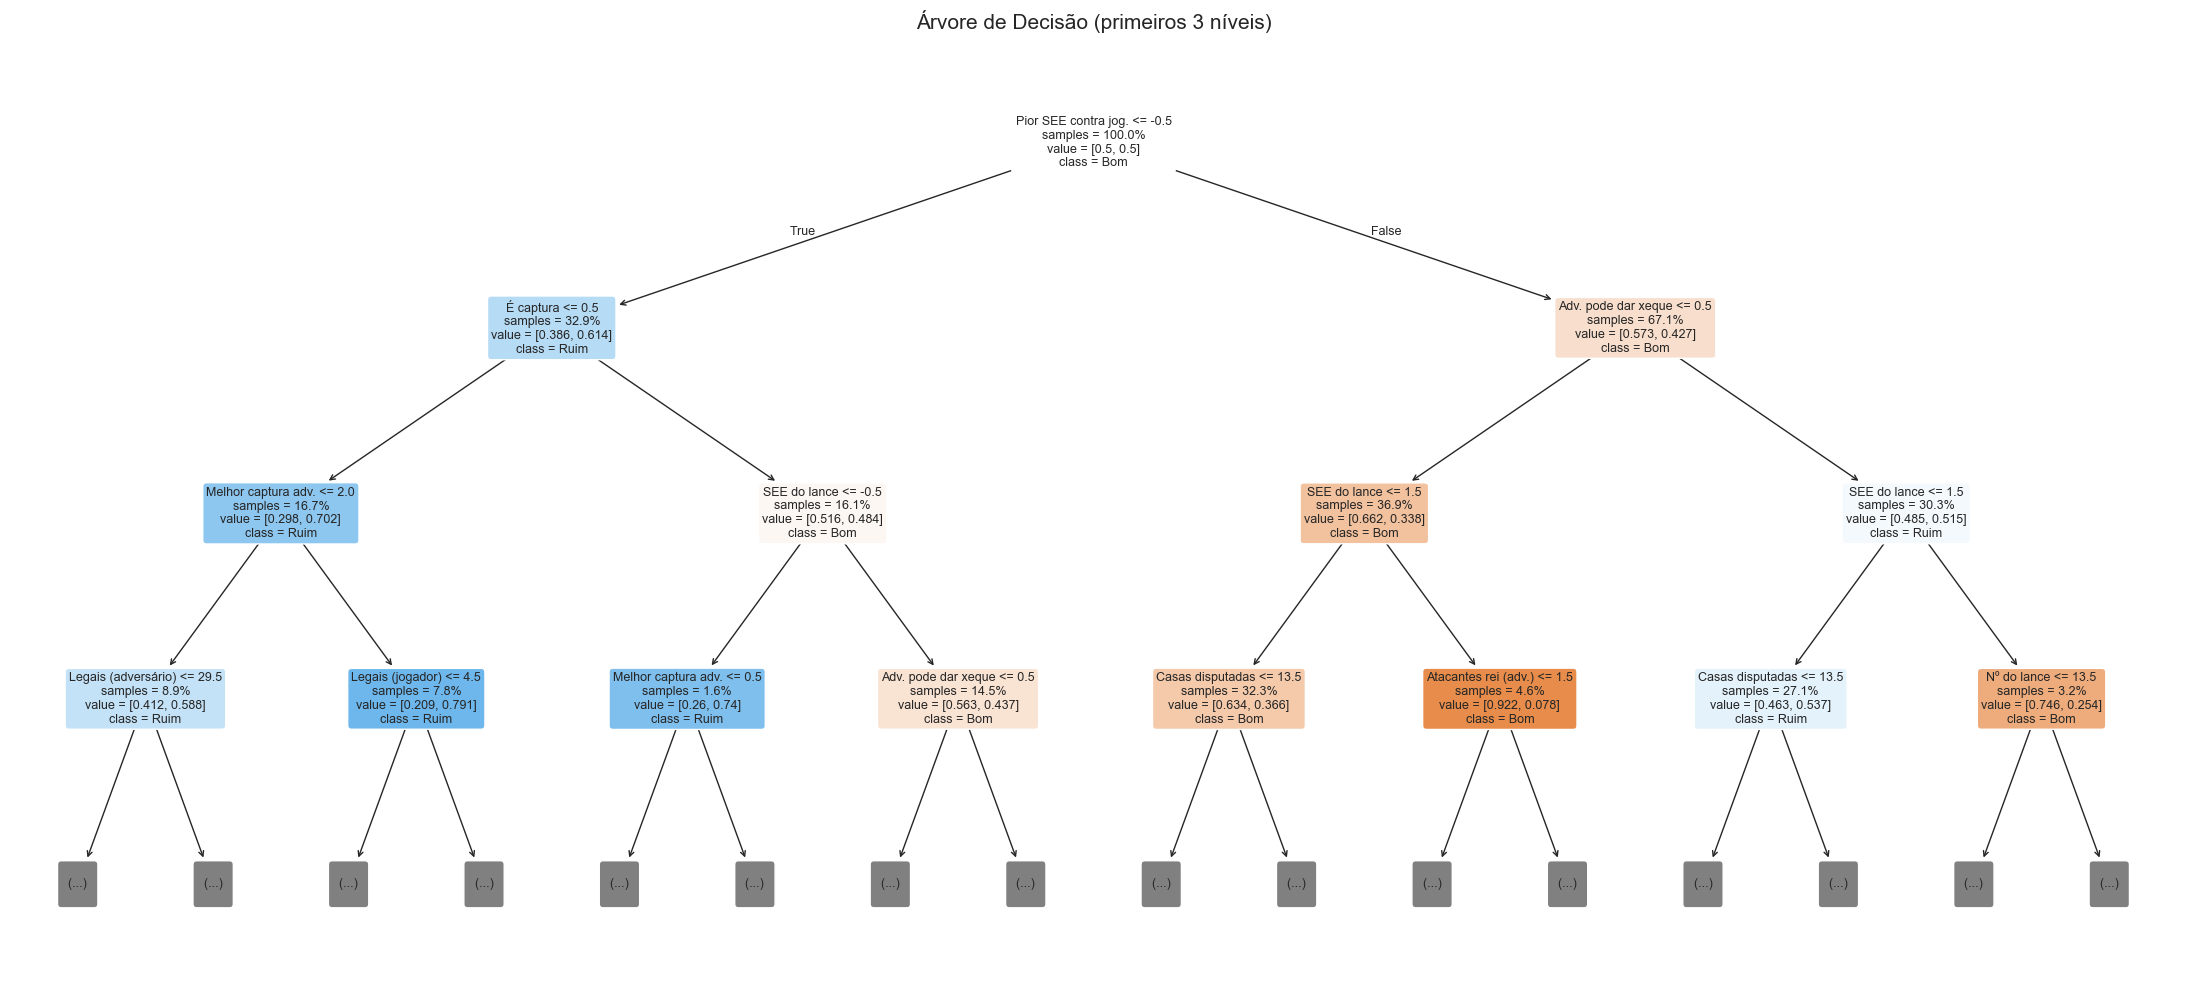

In [19]:
plot_decision_tree(dt, feature_names)

In [20]:
print_tree_rules(config)

═══════════════════════════════════════════════════════════
Regras da Árvore de Decisão V3 — Traduzidas para xadrez
═══════════════════════════════════════════════════════════

Legenda:
  - Δ = delta (diferença antes→depois do lance)
  - "Pior SEE contra jogador": pior resultado de troca de peças
  - "SEE do lance": resultado da sequência de capturas no destino
  - "Melhor captura adversário": valor da melhor captura disponível
  - "Adversário pode dar xeque": 1 se o lance permite xeque
  - Demais features: ver legenda V1/V2

═══════════════════════════════════════════════════════════

|--- Pior SEE contra jogador <= -0.50
|   |--- É captura <= 0.50
|   |   |--- Melhor captura adversário <= 2.00
|   |   |   |--- Lances legais (adversário) <= 29.50
|   |   |   |   |--- Dá xeque <= 0.50
|   |   |   |   |   |--- Diferença material <= -2.50
|   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |--- Diferença material >  -2.50
|   |   |   |   |   |   |--- truncated br

### Análise de Erros

In [21]:
show_error_examples(config)


  FALSOS POSITIVOS — Decision Tree V3
  (modelo disse "ruim", lance é bom)

  FP-1: Qd5 (lance #18, black)
    Delta: -6 cp | Partida: https://lichess.org/bRkKD0xN
    Features: Pior SEE contra jog.=0; SEE do lance=0; Adv. pode dar xeque=1; É captura=0; Melhor captura adv.=1

  FP-2: Qd6 (lance #24, black)
    Delta: -37 cp | Partida: https://lichess.org/tPBLHgbz
    Features: Pior SEE contra jog.=0; SEE do lance=0; Adv. pode dar xeque=1; É captura=0; Melhor captura adv.=3

  FP-3: Qd6+ (lance #39, black)
    Delta: -21 cp | Partida: https://lichess.org/lGGH9i2U
    Features: Pior SEE contra jog.=-1; SEE do lance=0; Adv. pode dar xeque=0; É captura=0; Melhor captura adv.=0

  FP-4: b6 (lance #19, black)
    Delta: -19 cp | Partida: https://lichess.org/yARNnTof
    Features: Pior SEE contra jog.=0; SEE do lance=0; Adv. pode dar xeque=1; É captura=0; Melhor captura adv.=1

  FP-5: Rhg1 (lance #30, white)
    Delta: 31 cp | Partida: https://lichess.org/XeWcCAqg
    Features: Pior SEE con

---

## 8. Conclusões V3

- **RF F1-ruim = 0.43** (+6.5 pp vs V2), **AUC = 0.77** (+6.0 pp) — o maior salto do projeto.
- **Meta AUC ≥ 0.75 atingida** (0.7678). Meta F1 ≥ 0.50 não atingida (0.4312).
- `worst_see_against_player` é feature #1: o resultado de trocas de peças supera todas as features posicionais e táticas.
- O recall caiu −4.95pp (V2→V3) mas precision subiu +9.78pp — trade-off favorável, modelo mais preciso.
- **Limitação fundamental:** look-ahead de 1 ply não captura combinações multi-lance ou erros posicionais profundos.